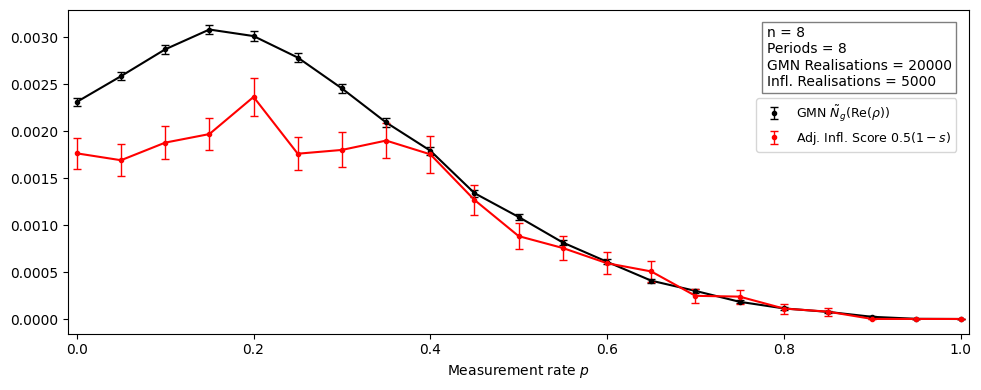

In [6]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


# infl_reals = 5000

# # import GMN data
# df = pd.read_csv('data.csv')
# data_array = df.to_numpy().transpose()
# gmn_ps = data_array[0]
# gmn_vals = data_array[1]

# # import GMN/circuit info
# df2 = pd.read_csv('info.csv')
# data_array2 = df2.to_numpy().transpose()
# n = int(data_array2[0][0])
# periods = int(data_array2[1][0])
# realizations = int(data_array2[2][0])
# res = int(data_array2[3][0])
# p_min = float(data_array2[4][0])
# p_max = float(data_array2[5][0])

# # import inflation data
# df3 = pd.read_csv('cpp/inflation_n_8_real_5k_all.csv')
# data_array3 = df3.to_numpy().transpose()
# infl_ps = data_array3[0]
# # i_gmn_vals = data_array3[1]
# infl_scores = data_array3[2]



# # get means +/- stds for real GMN
# ps_unique = list(set(gmn_ps))
# gmn_means = []
# gmn_stds = []
# for p in ps_unique:
#     values_for_p = [val for val, p_val in zip(gmn_vals, gmn_ps) if p_val == p]
#     gmn_means.append(np.mean(values_for_p))
#     gmn_stds.append(np.std(values_for_p, ddof=1)/np.sqrt(realizations*n))

# # get means +/- stds for inflation
# infl_ps_unique = list(set(infl_ps))
# infl_means = []
# infl_stds = []
# for p in infl_ps_unique:
#     infl_values_for_p = [infl for infl, p_val in zip(infl_scores, infl_ps) if p_val == p]
#     infl_means.append(np.mean(infl_values_for_p))
#     infl_stds.append(np.std(infl_values_for_p, ddof=1)/np.sqrt(infl_reals))

sorted_pairs = sorted(zip(ps_unique, gmn_means))
x_sorted, y_sorted = zip(*sorted_pairs)
# plot GMN
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1, label=r"GMN $\tilde{N}_g(\text{Re}(\rho))$")
ax1.set_xlabel('Measurement rate $p$')
ax1.plot(x_sorted, y_sorted, color='black')
# ax1.set_ylabel(r'GMN $\tilde{N}_g(\rho)$ = $-\min\;\text{tr}\.(\rho W)$')

sorted_pairs = sorted(zip(infl_ps_unique, infl_means))
x_sorted, y_sorted = zip(*sorted_pairs)
# plot inflation
scale = 0.5
ax1.errorbar(infl_ps_unique, [scale*(1 - m) for m in infl_means], yerr=scale*np.array(infl_stds), 
             fmt='.', color='red', ecolor='red', capsize=3, elinewidth=1, label=f"Adj. Infl. Score ${scale}(1-s)$")
ax1.plot(x_sorted, [scale*(1-m) for m in y_sorted], color='red')


props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.775, 0.95, f"n = {n}\nPeriods = {periods}\nGMN Realisations = {realizations}\nInfl. Realisations = {infl_reals}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax1.set_xlim(-0.01,1.01)

fig.legend(bbox_to_anchor=(0.9675, 0.675), loc="center right", fontsize=9)
fig.tight_layout()

In [ ]:
from mipt import *
import numpy as np

from mipt_rho3_bin_writer import Rho3BinWriter, ring_subsystem_qubits

n = 8
d = 2 * n
ps = np.linspace(0.0, 1.0, 21)
realisations = 1000

subsystem_qubits = ring_subsystem_qubits(n, closed=True)

with Rho3BinWriter(
    "rho3_python_archA.bin",
    total_qubits=n,
    subsystem_qubits=subsystem_qubits,
    periods=d,
    realizations=realisations,
    p_vals=ps,
) as writer:
    for p_index, p in enumerate(ps):
        print(f"Simulating p = {p}...")
        for r in range(realisations):
            rhos = get_mipt_rho_1d(
                n, d, p,
                subsyst=3,
                all_matrices=True,
                closed=True,
            )

            writer.write_record(
                p_index=p_index,
                realization=r,
                p=float(p),
                rhos=rhos,
            )
            print(f"Realisations: {r}/{realisations}", end='\r', flush=True)
        print()

Simulating p = 0.0...
Realisations: 999/1000
Simulating p = 0.05...
Realisations: 999/1000
Simulating p = 0.1...


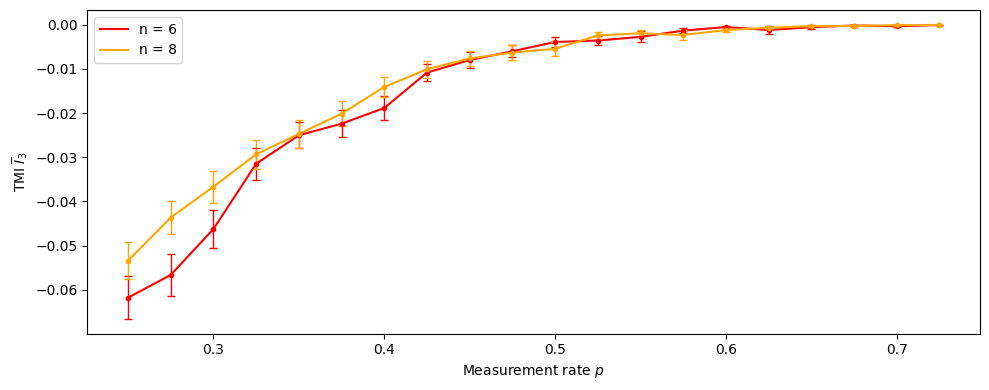

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

realisations = 5000
ns = [8, 12]
ps_arr, mean_arr, std_arr = [], [], []
for n in ns:
    print(f"Importing n = {n}...")
    df = pd.read_csv(f'csv/rho_tmi_python_fermion_n_{n}_real_5000_0.3_0.45.csv')
    data_array = df.to_numpy().transpose()

    ps = data_array[0]
    tmi_vals = data_array[1]
    ps_unique = list(set(ps))
    means = []
    stderrs = []
    for p in ps_unique:
        print(p, " ", end='')
        tmi_for_p = [_tmi for _tmi, p_val in zip(tmi_vals, ps) if p_val == p]
        means.append(np.mean(tmi_for_p))
        stderrs.append(np.std(tmi_for_p, ddof=1)/np.sqrt(realisations))
    print()
    sorted_args = sorted(zip(ps_unique, means, stderrs))
    ps_unique, means, stderrs = zip(*sorted_args)
    ps_arr.append(ps_unique)
    mean_arr.append(means)
    std_arr.append(stderrs)


colors = ["red", "orange", "green", "blue"]

START_INDEX = 10
END_INDEX = 30

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
for i in range(len(ns)):
    ax1.errorbar(ps_arr[i][START_INDEX:END_INDEX], mean_arr[i][START_INDEX:END_INDEX], yerr=std_arr[i][START_INDEX:END_INDEX], fmt='.', color=colors[i], ecolor=colors[i], capsize=3, elinewidth=1)
    ax1.plot(ps_arr[i][START_INDEX:END_INDEX], mean_arr[i][START_INDEX:END_INDEX], color=colors[i], label=f"n = {ns[i]}")
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel(r'TMI $\overline{I}_3$')

# props = dict(boxstyle='square', facecolor='white', alpha=0.5)
# ax1.text(0.75, 0.95, f"Realisations = {realisations}", transform=ax1.transAxes, fontsize=10,
#         verticalalignment='top', bbox=props)
 
ax1.legend()
fig.tight_layout()

In [76]:
import numpy as np
print(np.linspace(0.25, 0.35, 6))
# d = 4
# print(list(range(0, 2*d+1, d)))

[0.25 0.27 0.29 0.31 0.33 0.35]


Importing n = 8...
0.25  0.27  0.31  0.29  0.3299999999999999  
Importing n = 12...
0.25  0.27  0.31  0.29  0.3299999999999999  0.35  


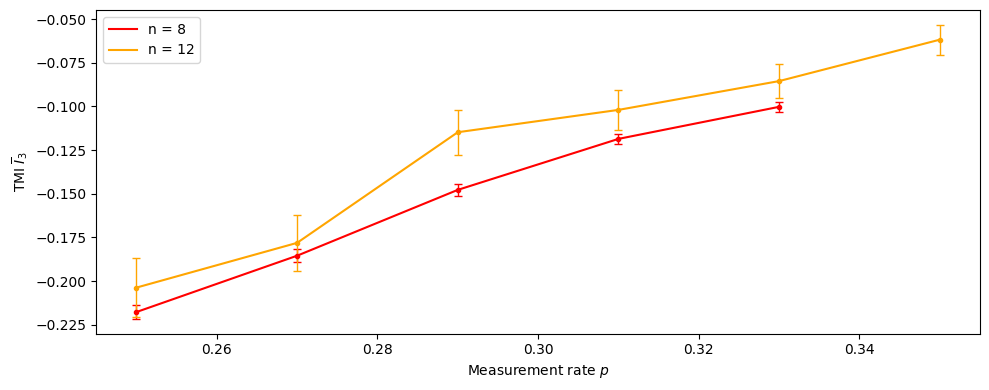

In [84]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

reals = [5000, 200]
ns = [8, 12]
ps_arr, mean_arr, std_arr = [], [], []
df1 = pd.read_csv(f'python_tmi_fermion_n_8.csv')
df2 = pd.read_csv(f'python_tmi_fermion_n_12.csv')
# df3 = pd.read_csv(f'csv/rho_tmi_fermion_n_16_real_5000_0.0_0.5.csv')
for i in range(len(ns)):
    n = ns[i]
    print(f"Importing n = {n}...")
    if n == 8:
        df = df1
    if n == 12:
        df = df2
    # if n == 16:
    #     df = df3

    data_array = df.to_numpy().transpose()

    ps: list
    tmi_vals: list
    ps = data_array[0]
    tmi_vals = data_array[1]
    # if n == 16:
    #     ps = data_array[0]
    #     tmi_vals = data_array[1]

    ps_unique = list(set(ps))
    means = []
    stderrs = []
    for p in ps_unique:
        print(p, " ", end='')
        tmi_for_p = [_tmi for _tmi, p_val in zip(tmi_vals, ps) if p_val == p]
        means.append(np.mean(tmi_for_p))
        stderrs.append(np.std(tmi_for_p, ddof=1)/np.sqrt(reals[i]))
    print()
    sorted_args = sorted(zip(ps_unique, means, stderrs))
    ps_unique, means, stderrs = zip(*sorted_args)
    ps_arr.append(ps_unique)
    mean_arr.append(means)
    std_arr.append(stderrs)


colors = ["red", "orange", "green", "blue"]

START_INDEX = 0
END_INDEX = 11

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
for i in range(len(ns)):
    # if ns[i] == 16:
    ax1.errorbar(ps_arr[i][START_INDEX:END_INDEX], mean_arr[i][START_INDEX:END_INDEX], yerr=std_arr[i][START_INDEX:END_INDEX], fmt='.', color=colors[i], ecolor=colors[i], capsize=3, elinewidth=1)
    ax1.plot(ps_arr[i][START_INDEX:END_INDEX], mean_arr[i][START_INDEX:END_INDEX], color=colors[i], label=f"n = {ns[i]}")
    # else:
    # ax1.errorbar(ps_arr[i], mean_arr[i], yerr=std_arr[i], fmt='.', color=colors[i], ecolor=colors[i], capsize=3, elinewidth=1)
    # ax1.plot(ps_arr[i], mean_arr[i], color=colors[i], label=f"n = {ns[i]}")
    
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel(r'TMI $\overline{I}_3$')

# props = dict(boxstyle='square', facecolor='white', alpha=0.5)
# ax1.text(0.75, 0.95, f"Realisations = {realisations}", transform=ax1.transAxes, fontsize=10,
#         verticalalignment='top', bbox=props)
 
ax1.legend()
fig.tight_layout()